### 8.1.2 训练

In [46]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

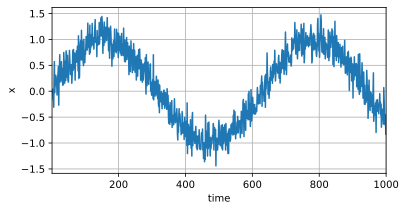

In [47]:
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(time * 0.01) + torch.normal(mean=0, std=0.2, size=(T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=[6, 3])

In [48]:
tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i:T - tau + i]
labels = x[tau:].reshape((-1, 1))

In [49]:
batch_size, n_train = 16, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

In [50]:
def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)


def get_net():
    net = nn.Sequential(
        nn.Linear(4, 10),
        nn.ReLU(),
        nn.Linear(10, 1)
    )
    net.apply(init_weight)
    return net


loss = nn.MSELoss(reduction='none')

In [51]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.SGD(net.parameters(), lr)

    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            # print(net[0].weight.grad)
            trainer.step()
        print(f'epoch: {epoch + 1}, loss {d2l.evaluate_loss(net, train_iter, loss)}')


net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch: 1, loss 0.055774988134702046
epoch: 2, loss 0.05287162641684214
epoch: 3, loss 0.049441477408011754
epoch: 4, loss 0.04996422119438648
epoch: 5, loss 0.048332768628994625


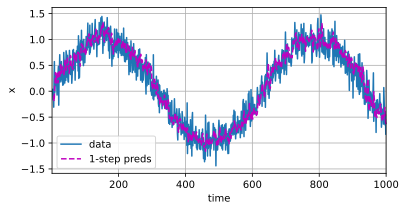

In [52]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]], [x.detach().numpy(), onestep_preds.detach().numpy()], 'time', 'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=[6, 3])

In [54]:
multistep_preds = torch.zeros(T)
multistep_preds[:n_train + tau] = x[:n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(multistep_preds[i - tau:i].reshape((1, -1)))

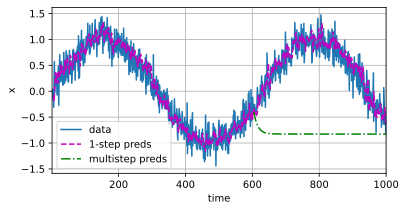

In [55]:
d2l.plot([time, time[tau:], time[n_train + tau:]], [x.detach().numpy(), onestep_preds.detach().numpy(), multistep_preds[n_train + tau:].detach().numpy()], 'time', 'x', legend=['data', '1-step preds', 'multistep preds'], xlim=[1, 1000],
         figsize=[6, 3])

In [62]:
max_steps = 64

In [64]:
features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))

for i in range(tau):
    features[:, i] = x[i:i + T - tau - max_steps + 1]

for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

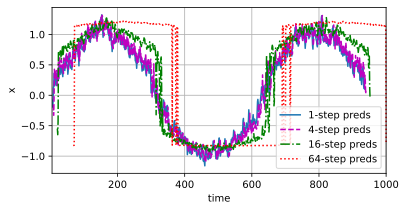

In [65]:
steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
         [features[:, (tau + i - 1)].detach().numpy() for i in steps], 'time', 'x',
         legend=[f'{i}-step preds' for i in steps], xlim=[5, 1000],
         figsize=(6, 3))